### punto 4

In [1]:
!pip install control

In [2]:
# Modelo del sistema y respuestas impulso/escalón
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from control.matlab import *   # funciones estilo MATLAB

In [ ]:
# Parámetros del sistema
R = 0.5
Cs = 2
Cp = 0.2

# Funciones de transferencia
# X(s) = G1(s)F(s) - G2(s)Fo(s)

# G1(s) = (Cs*Cp*R*s + Cp) / ((R*Cs + R*Cp)*s + 1)
num_G1 = [Cs*Cp*R, Cp]
den_G1 = [R*Cs + R*Cp, 1]
G1 = ctrl.TransferFunction(num_G1, den_G1)

# G2(s) = (Cp*s) / ((R*Cs + R*Cp)*s + 1)
num_G2 = [Cp, 0]
den_G2 = [R*Cs + R*Cp, 1]
G2 = ctrl.TransferFunction(num_G2, den_G2)

print("G1(s) =", G1)
print(" ")
print("G2(s) =", G2)

G1(s) = <TransferFunction>: sys[4]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  0.2 s + 0.2
  -----------
   1.1 s + 1
 
G2(s) = <TransferFunction>: sys[5]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    0.2 s
  ---------
  1.1 s + 1


c:\Users\USUARIO\anaconda3\Lib\site-packages\control\timeresp.py:2015: UserWarning: System has direct feedthrough: `D != 0`. The infinite impulse at `t=0` does not appear in the output.
Results may be meaningless!
  warnings.warn("System has direct feedthrough: `D != 0`. The "


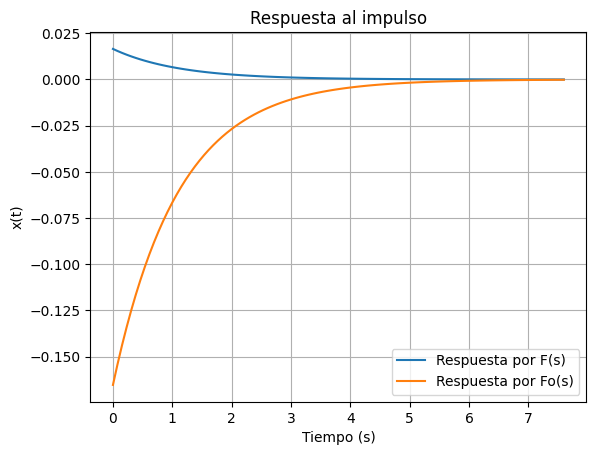

In [29]:
# Respuesta al impulso

t1, y1 = ctrl.impulse_response(G1)

plt.figure(1)
plt.plot(t1, y1, label="Respuesta por F(s)")

t2, y2 = ctrl.impulse_response(G2)
plt.plot(t2, y2, label="Respuesta por Fo(s)")

plt.title("Respuesta al impulso")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

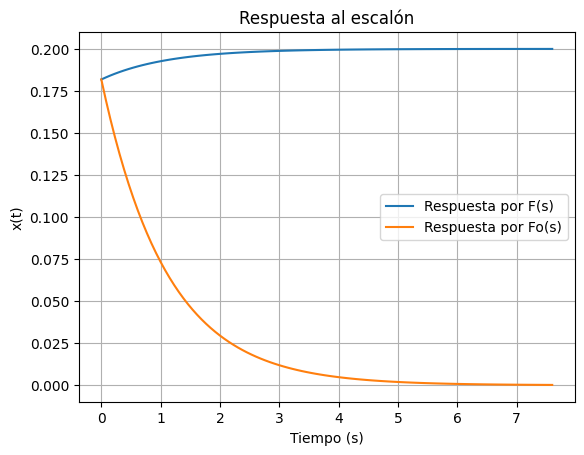

In [28]:
# Respuesta al escalón

t2, y2 = ctrl.step_response(G1)

plt.figure(2)
plt.plot(t2, y2, label="Respuesta por F(s)")

t3, y3 = ctrl.step_response(G2)
plt.plot(t3, y3, label="Respuesta por Fo(s)")

plt.title("Respuesta al escalón")
plt.xlabel("Tiempo (s)")
plt.ylabel("x(t)")
plt.legend()
plt.grid()

plt.show()

In [18]:
# Tiempo de muestreo
Ts = 0.1

# Transformada Z (discretización)
G1z = ctrl.c2d(G1, Ts, method='zoh')
G2z = ctrl.c2d(G2, Ts, method='zoh')

print("\nG1(z) =")
print(G1z)

print("\nG2(z) =")
print(G2z)



G1(z) =
<TransferFunction>: sys[4]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.1818 z - 0.1644
  -----------------
     z - 0.9131

G2(z) =
<TransferFunction>: sys[5]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
dt = 0.1

  0.1818 z - 0.1818
  -----------------
     z - 0.9131


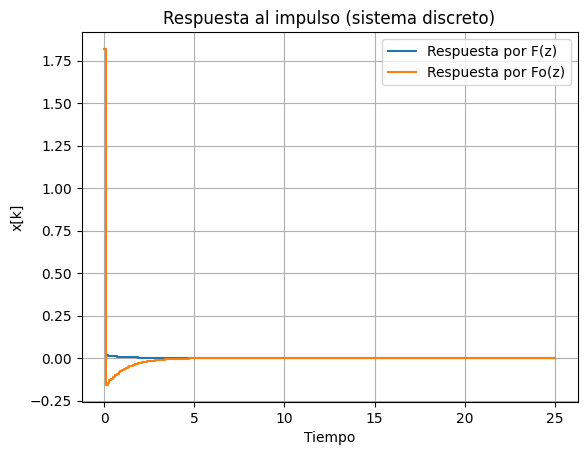

In [27]:
# Respuesta impulso (sistema discreto)

t_imp, y_imp = ctrl.impulse_response(G1z)

plt.figure(3)
plt.step(t_imp, y_imp, where="post", label="Respuesta por F(z)")

t2_imp, y2_imp = ctrl.impulse_response(G2z)
plt.step(t2_imp, y2_imp, where="post", label="Respuesta por Fo(z)")

plt.title("Respuesta al impulso (sistema discreto)")
plt.xlabel("Tiempo")
plt.ylabel("x[k]")
plt.legend()
plt.grid()

plt.show()

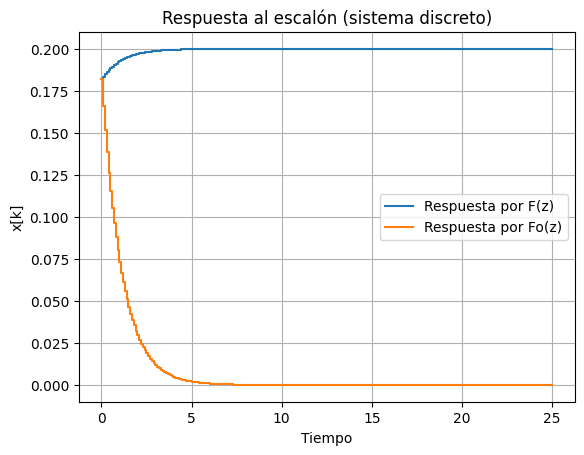

In [26]:
# Respuesta escalón (sistema discreto)

t_step, y_step = ctrl.step_response(G1z)

plt.figure(4)
plt.step(t_step, y_step, where="post", label="Respuesta por F(z)")

t2_step, y2_step = ctrl.step_response(G2z)
plt.step(t2_step, y2_step, where="post", label="Respuesta por Fo(z)")

plt.title("Respuesta al escalón (sistema discreto)")
plt.xlabel("Tiempo")
plt.ylabel("x[k]")
plt.legend()
plt.grid()

plt.show()